# Supervised Learning: KNNs and Linear Models

We covered the following ML algorithms in morning lecture:
- knn
- simple linear regression

In this notebook we will focus on 
- introducting building and evaluating models with sklearn
- exploring KNN's hyperparameters effects on performance
- introduce building simple linear regression models with sklearn

## import modules 

In [1]:
%matplotlib notebook
import numpy as np
import pandas as pd
#import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from sklearn import neighbors
import matplotlib.patches as mpatches

# import functions from plotting helper script
from plotting_knns import *

%matplotlib inline

## K-Nearest Neighbour classification 

For this example, we use the iris data set. https://archive.ics.uci.edu/ml/datasets/iris

The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by the British statistician and biologist Ronald Fisher in his 1936 paper "The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis".

The data set consists of 150 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, Fisher developed a linear discriminant model to distinguish the species from each other.

### Get data and print description

In [2]:
# get data and print information about it 
from sklearn import datasets

iris = datasets.load_iris() # get data

print('The iris.data has {} samples each of which has {} features. e.g. first two data: {}'
      .format(iris.data.shape[0], iris.data.shape[1], iris.data[:2]))
print('The iris.target has labels (one of {}) for {} samples. e.g. first two labels {}'
      .format(iris.target_names, iris.target.shape[0], iris.target[:2]))

print(iris.DESCR)

The iris.data has 150 samples each of which has 4 features. e.g. first two data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
The iris.target has labels (one of ['setosa' 'versicolor' 'virginica']) for 150 samples. e.g. first two labels [0 0]
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9 

### Get selected features and targets from iris data set for training

X represents the features and y represents the targets. 

In [3]:
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

### Plot data 

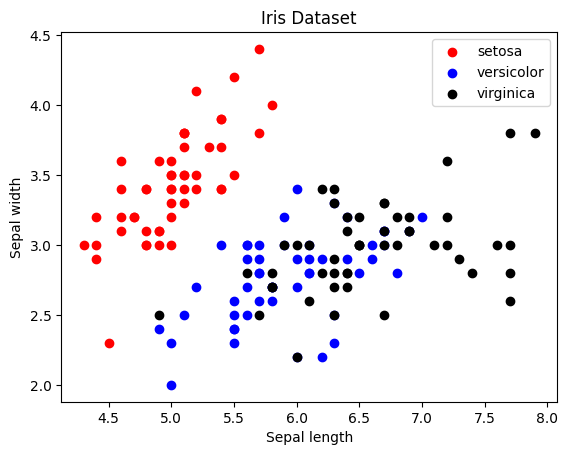

In [4]:
color_list_bold = [ '#FF0000', '#0000FF', '#000000']
labels={0:'setosa',1:'versicolor',2:'virginica'}
fig,ax=plt.subplots()
for i in range(3):
    ax.scatter(X[y==i, 0], X[y==i, 1],label=labels[i],color=color_list_bold[i])
ax.set_xlabel('Sepal length')
ax.set_ylabel('Sepal width')
ax.set_title('Iris Dataset')
ax.legend();

### Build a KNN Classification Model 

In [5]:
from sklearn.neighbors import KNeighborsClassifier # import model 

#### Train/Test Split 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 0)

#### Train model 

See documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [7]:
knn = KNeighborsClassifier(n_neighbors = 10)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

#### Evaluate Model 

In [8]:
print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(knn.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(knn.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.85
Accuracy of K-NN classifier on test set: 0.63


Below is sklearn's classification report.  This includes alternative classification metrics to accuracy. 

In [9]:
from sklearn.metrics import classification_report  # includes various metrics for evaluating classification models
y_pred=knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.62      0.38      0.48        13
   virginica       0.27      0.50      0.35         6

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.61        30
weighted avg       0.69      0.63      0.64        30



Below we visualize a confusion matrix.

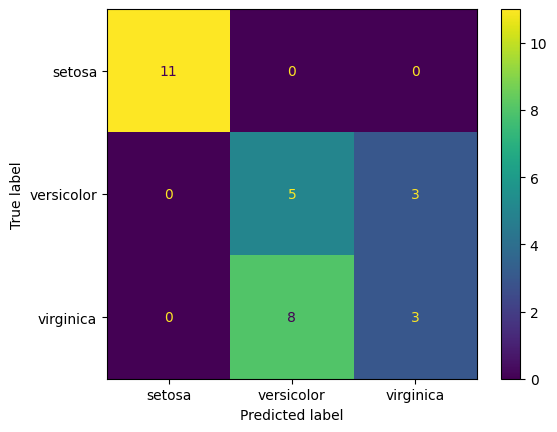

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # computes and visually displays the confusion matrix 
cm=confusion_matrix(y_pred, y_test) #,labels=['setosa','versicolor','virginica'])
cm_display = ConfusionMatrixDisplay(cm,display_labels=['setosa','versicolor','virginica']).plot()

#### Predict with Model 

Finally, we may want to use our model to make predictions on unseen data points.  Below, we demo how this can be done. 

In [11]:
examples = [[5.9,  3.], [4.4, 1.9]]
predictions= knn.predict(examples)

print('Predicted iris type for ', examples, ' is ', 
          [iris.target_names[x] for x in predictions ] )

Predicted iris type for  [[5.9, 3.0], [4.4, 1.9]]  is  [np.str_('versicolor'), np.str_('versicolor')]


#### OPTIONAL EXERCISE

In the demo above we trained and evaluated a KNN model with k=10.  Using the Iris dataset as defined in variables X and Y above, train a KNN model with k = 1 and k = 50 and compute the accuracy of each model with testing data.  What is the best value of k: 1,10 or 50?

### Solutions

In [12]:
# build model 
def build_evaluate_model(k,X_train, X_test, y_train, y_test):
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    
    # get predictions for testing data  
    y_pred=knn.predict(X_test)
    
    # evaluate model with classification report 
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    
    # evaluate model with confusion matrix 
    cm=confusion_matrix(y_pred, y_test) #,labels=['setosa','versicolor','virginica'])
    cm_display = ConfusionMatrixDisplay(cm,display_labels=['setosa','versicolor','virginica']).plot()

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.64      0.54      0.58        13
   virginica       0.25      0.33      0.29         6

    accuracy                           0.67        30
   macro avg       0.63      0.62      0.62        30
weighted avg       0.69      0.67      0.68        30



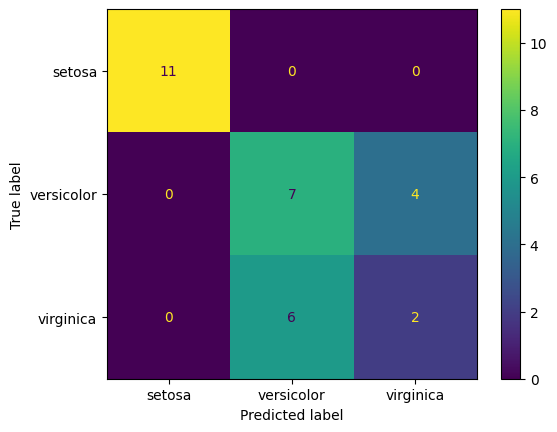

In [13]:
build_evaluate_model(1,X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.62      0.38      0.48        13
   virginica       0.27      0.50      0.35         6

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.61        30
weighted avg       0.69      0.63      0.64        30



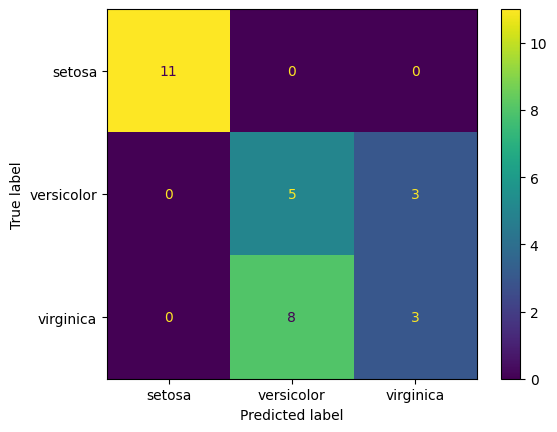

In [14]:
build_evaluate_model(10,X_train, X_test, y_train, y_test)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.73      0.62      0.67        13
   virginica       0.38      0.50      0.43         6

    accuracy                           0.73        30
   macro avg       0.70      0.71      0.70        30
weighted avg       0.76      0.73      0.74        30



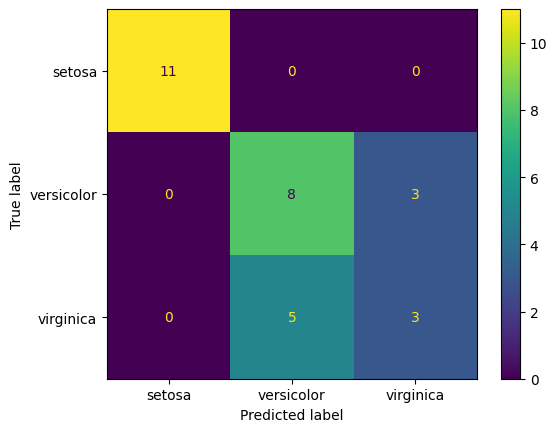

In [15]:
build_evaluate_model(50,X_train, X_test, y_train, y_test)

## Visualizing Decision Boundaries 

We have a a helper functions which we have imported into this notebook called `plot_two_class_knn`.  This function does the following:
1. trains a KNN model with training data and hyperparameters provided 
2. plots the decision boundary for the model produced
3. evaluates model with training and testing data; reports numbers in title of plot.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


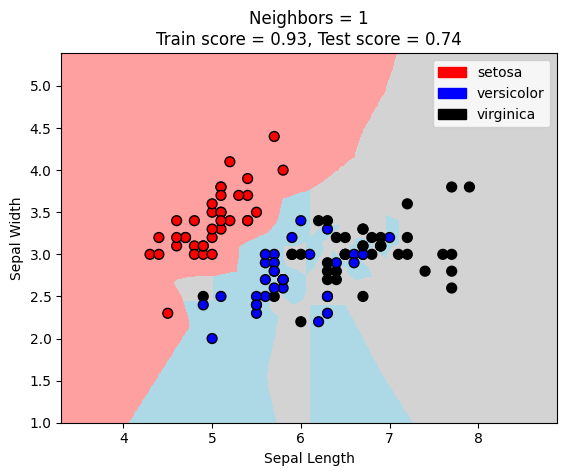

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   random_state=0)
plot_two_class_knn(X_train,  # training data: features
                   y_train,  # training data: labels
                   1,        # hyperparameter: k
                   X_test,   # testing data: features
                   y_test,   # testing data: labels
                   label=labels) # dictionary mapping numerical values of targets to text description for legend; 
                                 # if no labels provided, no legend appears

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


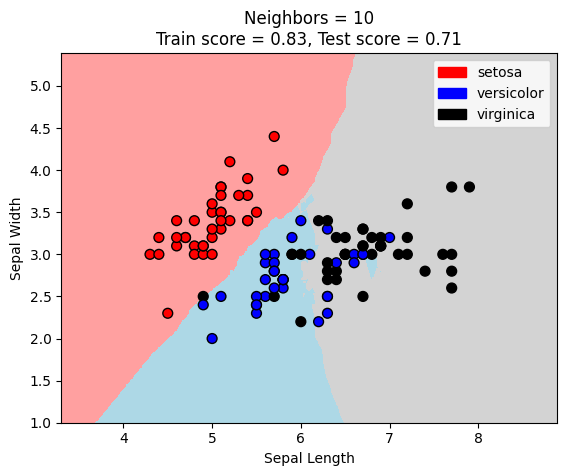

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


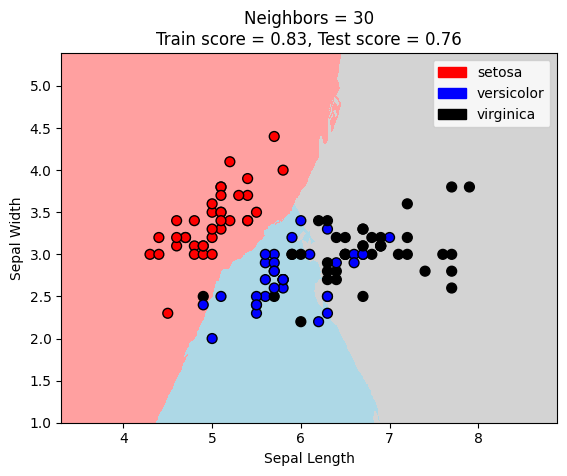

In [17]:
plot_two_class_knn(X_train, y_train, 10, X_test, y_test,label=labels)
plot_two_class_knn(X_train, y_train, 30, X_test, y_test,label=labels)

#### Find the ideal value of k 

To find the ideal value of k lets build a several models with different values of k and evaluate the performance a

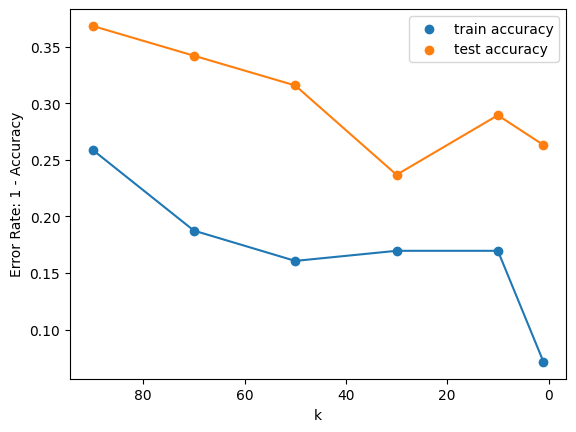

In [18]:
ks = [1,10,30,50,70,90]
accuracy_train = []
accuracy_test = []
for k in ks:
    # train model
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    # evaluate model: We will use error rate or 1 - accuracy so that the ideal score is a minimum 
    accuracy_train.append(1- knn.score(X_train, y_train))
    accuracy_test.append(1- knn.score(X_test, y_test))

# plot performance vs k
fig,ax=plt.subplots()
ax.plot(ks, accuracy_train)
ax.plot(ks, accuracy_test)
ax.scatter(ks, accuracy_train, label='train accuracy')
ax.scatter(ks, accuracy_test, label='test accuracy')
ax.set_xlabel('k')
ax.set_ylabel('Error Rate: 1 - Accuracy')
ax.legend()
ax.invert_xaxis()

#### OPTIONAL EXERCISE

Below we have code that creates and visualizes a synthetic data set (X_C2, y_C2). Try to find the ideal value of k for this dataset by building multiple models and comparing performance. 

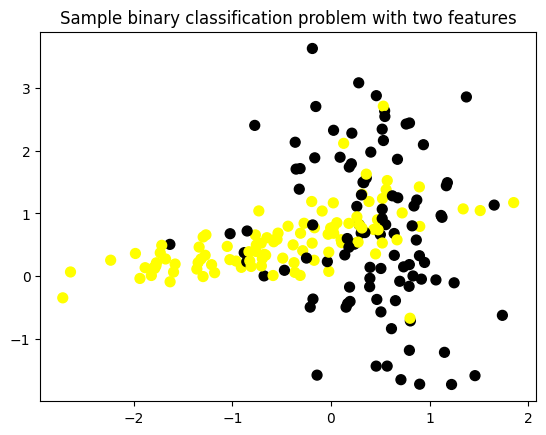

In [19]:
# synthetic dataset for classification (binary) 
plt.figure()
plt.title('Sample binary classification problem with two features')

# create synthetic dataset 
X_C2, y_C2 = make_classification(n_samples = 200, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)

# plot synthetic dataset
cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000']) 
plt.scatter(X_C2[:, 0], X_C2[:, 1], c=y_C2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()

### Solutions

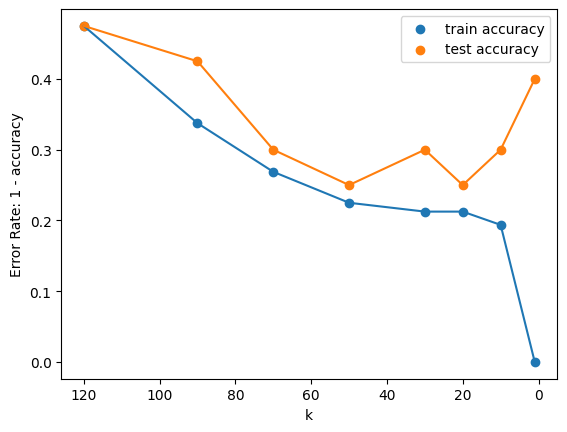

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, train_size=0.8, random_state = 0)

ks = [1,10,20,30,50,70,90,120]
accuracy_train = []
accuracy_test = []
for k in ks:
    # train model
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)

    # evaluate model
    accuracy_train.append(1- knn.score(X_train, y_train))
    accuracy_test.append(1- knn.score(X_test, y_test))

# plot performance vs k
fig,ax=plt.subplots()
ax.plot(ks, accuracy_train)
ax.plot(ks, accuracy_test)
ax.scatter(ks, accuracy_train, label='train accuracy')
ax.scatter(ks, accuracy_test, label='test accuracy')
ax.set_xlabel('k')
ax.set_ylabel('Error Rate: 1 - accuracy')
ax.legend()
ax.invert_xaxis()

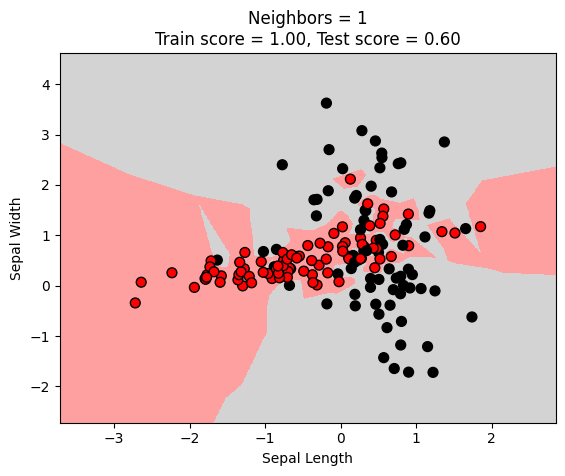

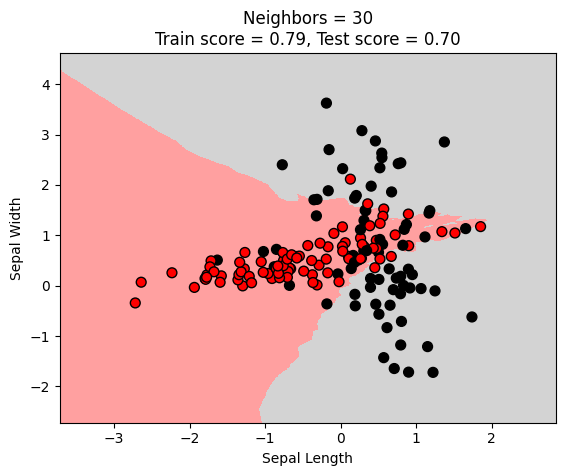

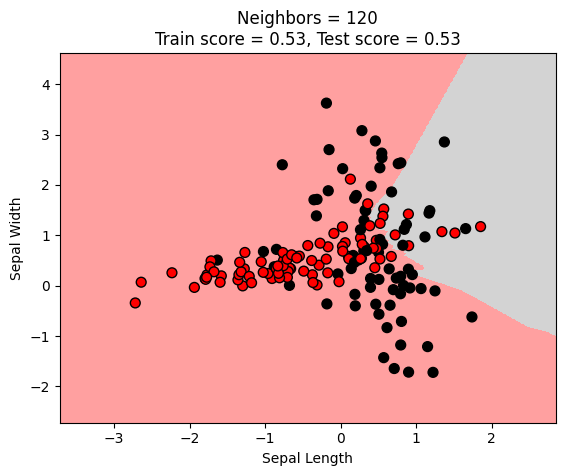

In [21]:
plot_two_class_knn(X_train, y_train, 1, X_test, y_test)
plot_two_class_knn(X_train, y_train, 30, X_test, y_test)
plot_two_class_knn(X_train, y_train, 120, X_test, y_test)

## Linear Regression 

### linear regression with synthetic binary data for simple linear regression

#### import modules

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

#### make and plot synthetic dataset

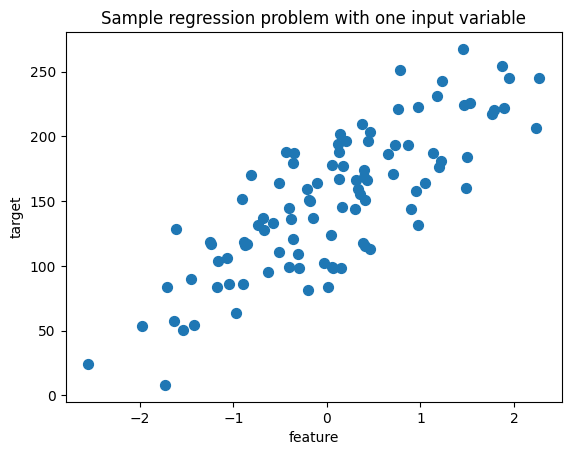

In [23]:
# get data 
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)

# plot data 
plt.figure()
plt.title('Sample regression problem with one input variable')
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.xlabel('feature')
plt.ylabel('target')
plt.show()

#### train test split and model training 

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

#### Evaluate model 

In [25]:
print('linear model coeff (w): {}'
     .format(linreg.coef_))
print('linear model intercept (b): {:.3f}'
     .format(linreg.intercept_))
print('R-squared score (training): {:.3f}'
     .format(linreg.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linreg.score(X_test, y_test)))

linear model coeff (w): [45.70870465]
linear model intercept (b): 148.446
R-squared score (training): 0.679
R-squared score (test): 0.492


#### Plot Model 

# Plot model vs training data

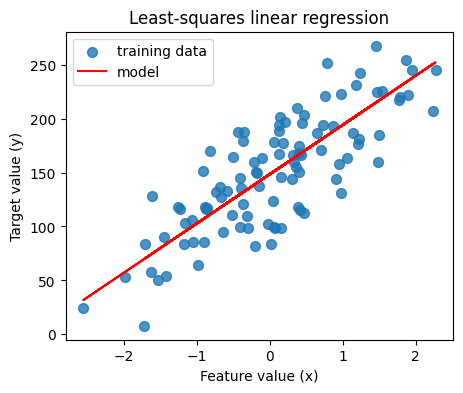

In [26]:
plt.figure(figsize=(5,4))
plt.scatter(X_R1, y_R1, marker= 'o', s=50, alpha=0.8, label='training data')
plt.plot(X_R1, linreg.coef_ * X_R1 + linreg.intercept_, 'r-', label='model')
plt.title('Least-squares linear regression')
plt.xlabel('Feature value (x)')
plt.ylabel('Target value (y)')
plt.legend()
plt.show()